# Tempo de execução: Produto escalar-vetor

Neste notebook faremos a comparação de tempo de execução entre a nossa função e a função `numpy.dot` do numpy. Utilizaremos a função [`timeit`](https://ipython.readthedocs.io/en/stable/interactive/magics.html#magic-timeit).

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from numba import njit
import my_functions as mf

In [2]:
N = np.array([100, 300, 500, 700, 1000, 10000])

In [3]:
list_time_dumb = []
list_time_numpy = []
for Ni in N:
    scalar = 1
    vector = np.ones(Ni)
    # scalar_vec_real_dumb
    time = %timeit -o -n 100 -r 50 mf.scalar_vec_real(scalar, vector, check_input=False)
    list_time_dumb.append(time.average)
    # scalar_vec_real_numpy
    time = %timeit -o -n 100 -r 50 scalar*vector
    list_time_numpy.append(time.average)

19.7 μs ± 6.35 μs per loop (mean ± std. dev. of 50 runs, 100 loops each)
1.14 μs ± 175 ns per loop (mean ± std. dev. of 50 runs, 100 loops each)
51.3 μs ± 690 ns per loop (mean ± std. dev. of 50 runs, 100 loops each)
1.22 μs ± 287 ns per loop (mean ± std. dev. of 50 runs, 100 loops each)
88.7 μs ± 739 ns per loop (mean ± std. dev. of 50 runs, 100 loops each)
1.25 μs ± 222 ns per loop (mean ± std. dev. of 50 runs, 100 loops each)
125 μs ± 777 ns per loop (mean ± std. dev. of 50 runs, 100 loops each)
1.36 μs ± 300 ns per loop (mean ± std. dev. of 50 runs, 100 loops each)
181 μs ± 1.39 μs per loop (mean ± std. dev. of 50 runs, 100 loops each)
1.41 μs ± 278 ns per loop (mean ± std. dev. of 50 runs, 100 loops each)
1.9 ms ± 20.3 μs per loop (mean ± std. dev. of 50 runs, 100 loops each)
2.98 μs ± 339 ns per loop (mean ± std. dev. of 50 runs, 100 loops each)


In [4]:
list_time_dumb = np.array(list_time_dumb)
list_time_numpy = np.array(list_time_numpy)

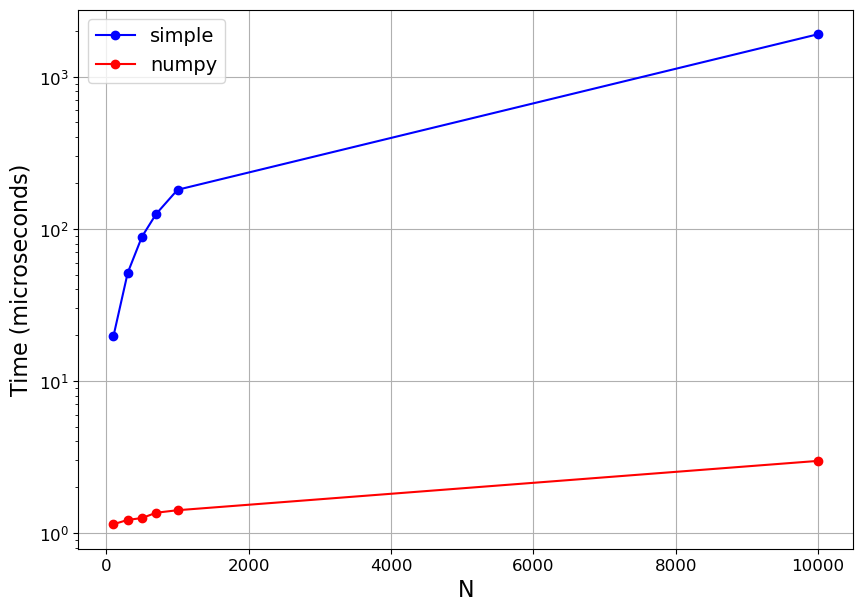

In [5]:
plt.figure(figsize=(10,7))
plt.plot(N, list_time_dumb*1e6, 'bo-', label = 'simple')
plt.plot(N, list_time_numpy*1e6, 'ro-', label = 'numpy')
plt.legend(loc = 'best', fontsize = 14)
plt.xticks(fontsize = 12)
plt.yticks(fontsize = 12)
plt.xlabel('N', fontsize = 16)
plt.ylabel('Time (microseconds)', fontsize = 16)
plt.yscale('log')
plt.grid()
plt.show()